# Visualisation notebook – VF074

Ce notebook sert à tester rapidement les fonctions de visualisation pour **VF074** :
- tous les plots globaux de la souris
- les plots de la **dernière session**
- option de sauvegarde en PNG

Il suppose que tes fonctions sont soit :
1. dans un fichier Python séparé (`app_functions.py` par exemple),
2. soit déjà définies dans le notebook.


In [1]:
from pathlib import Path
import importlib.util
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# CONFIG
# ============================================================
FEATHER_PATH = Path(
    r"\\SynoINVIBE_Caze\INVIBE_team_Cazettes\data\database\full_db_all_rigs.feather"
)

MOUSE_ID = "VF074"
SAVE_PLOTS = False
OUTPUT_DIR = Path("vf074_plot_exports")

# Si tes fonctions sont dans un fichier .py, mets son chemin ici.
# Exemple : MODULE_PATH = Path(r"C:/Users/ton_nom/Documents/analysis/app_functions.py")
MODULE_PATH = Path(r"C:\Users\admaberlenc.a\Documents\app\app_functions.py")    

print(f"FEATHER_PATH: {FEATHER_PATH}")
print(f"MOUSE_ID: {MOUSE_ID}")


FEATHER_PATH: \\SynoINVIBE_Caze\INVIBE_team_Cazettes\data\database\full_db_all_rigs.feather
MOUSE_ID: VF074


## Chargement des fonctions

Si les fonctions sont déjà dans le notebook, cette cellule ne fait rien.
Sinon, mets `MODULE_PATH` vers ton fichier Python qui contient les fonctions.


In [2]:
required_function_names = [
    "prepare_mouse_dataframe",
    "plot_protocol_strip",
    "plot_bout_count_rewards",
    "plot_stacked_lick_counts",
    "plot_histogram_kde_failures",
    "plot_kde_failures_by_session",
    "plot_regression_rewards_failures_and_slope",
    "build_session_plot_rewards_vs_failures",
    "build_session_plot_failure_distribution",
]

missing = [name for name in required_function_names if name not in globals()]

if missing and MODULE_PATH is not None:
    MODULE_PATH = Path(MODULE_PATH)
    spec = importlib.util.spec_from_file_location("viz_module", MODULE_PATH)
    viz_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(viz_module)

    for name in required_function_names:
        if hasattr(viz_module, name):
            globals()[name] = getattr(viz_module, name)

missing = [name for name in required_function_names if name not in globals()]

if missing:
    raise RuntimeError(
        "Fonctions manquantes : " + ", ".join(missing) +
        "\n\nDéfinis-les dans le notebook ou renseigne MODULE_PATH vers le fichier .py qui les contient."
    )
else:
    print("Toutes les fonctions nécessaires sont disponibles.")


Toutes les fonctions nécessaires sont disponibles.


## Chargement de la base

In [3]:
df_raw = pd.read_feather(FEATHER_PATH)
df, session_cmap = prepare_mouse_dataframe(df_raw)

df_mouse = df[df["Mouse_ID"] == MOUSE_ID].copy()
df_mouse = df_mouse.sort_values(["Date", "Version"]).reset_index(drop=True)

if df_mouse.empty:
    raise ValueError(f"Aucune donnée trouvée pour {MOUSE_ID}")

print(f"Nombre total de sessions pour {MOUSE_ID}: {len(df_mouse)}")
display(df_mouse[["Mouse_ID", "Date", "Version", "Protocol", "Probas"]].tail(10))


Nombre total de sessions pour VF074: 26


,Mouse_ID,Date,Version,Protocol,Probas
16,VF074,2026-03-05,1,3,0.9/0.3
17,VF074,2026-03-06,1,3,0.9/0.3
18,VF074,2026-03-09,1,3,0.9/0.3
19,VF074,2026-03-10,1,3,0.9/0.3
20,VF074,2026-03-11,1,3,0.9/0.3
21,VF074,2026-03-16,1,2,0.9/0.3
22,VF074,2026-03-17,1,3,0.9/0.3
23,VF074,2026-03-18,1,3,0.9/0.3
24,VF074,2026-03-19,1,3,0.9/0.3
25,VF074,2026-03-20,1,3,0.9/0.3


## Dernière session

In [4]:
last_session = df_mouse.iloc[-1]
last_date = pd.to_datetime(last_session["Date"]).strftime("%Y-%m-%d")

print("Dernière session:")
print(f"- Mouse: {MOUSE_ID}")
print(f"- Date: {last_date}")
print(f"- Version: {last_session['Version']}")
print(f"- Protocol: {last_session['Protocol']}")
print(f"- Probas: {last_session['Probas']}")


Dernière session:
- Mouse: VF074
- Date: 2026-03-20
- Version: 1
- Protocol: 3
- Probas: 0.9/0.3


## Helper d'affichage / sauvegarde

In [5]:
def maybe_save(fig, name: str):
    if not SAVE_PLOTS or fig is None:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = OUTPUT_DIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", dpi=200)
    print(f"Saved -> {out}")


def show_fig(fig, name: str):
    if fig is None:
        print(f"[SKIP] {name} : aucune donnée exploitable")
        return
    maybe_save(fig, name)
    plt.show()


## Tous les plots globaux de VF074


=== protocol_strip ===


C:\Users\admaberlenc.a\Documents\app\app_functions.py:943: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


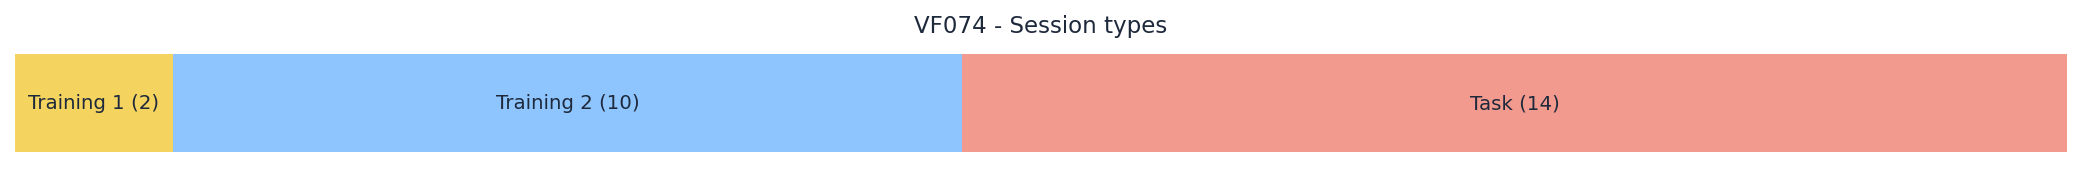

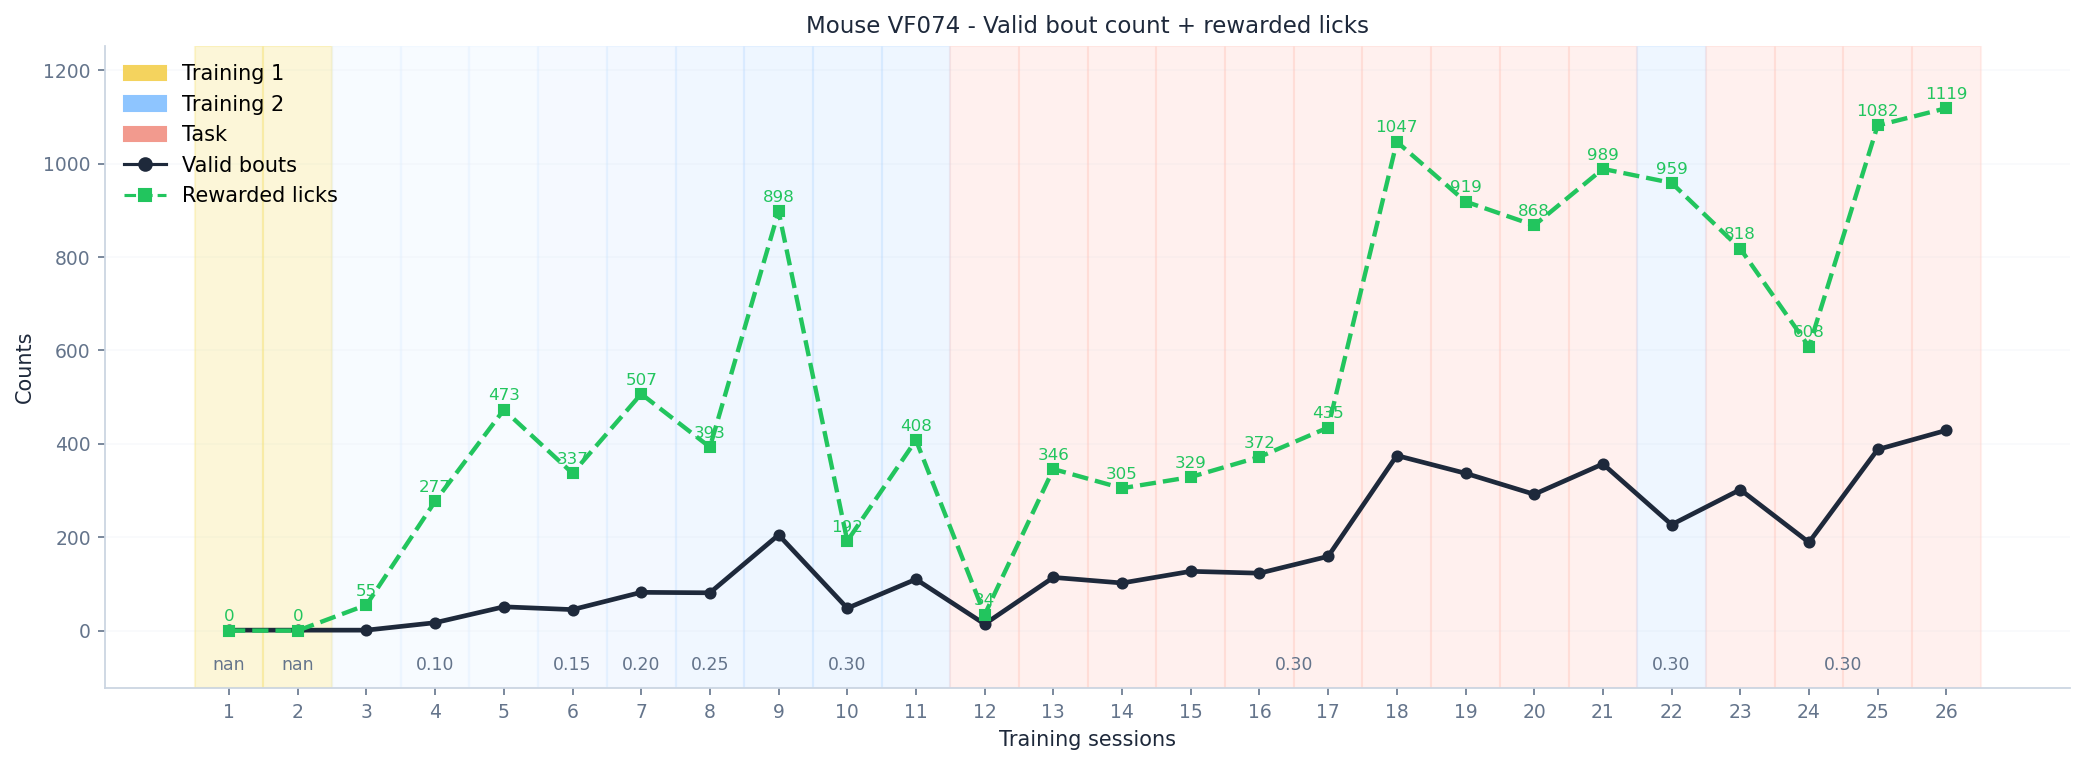

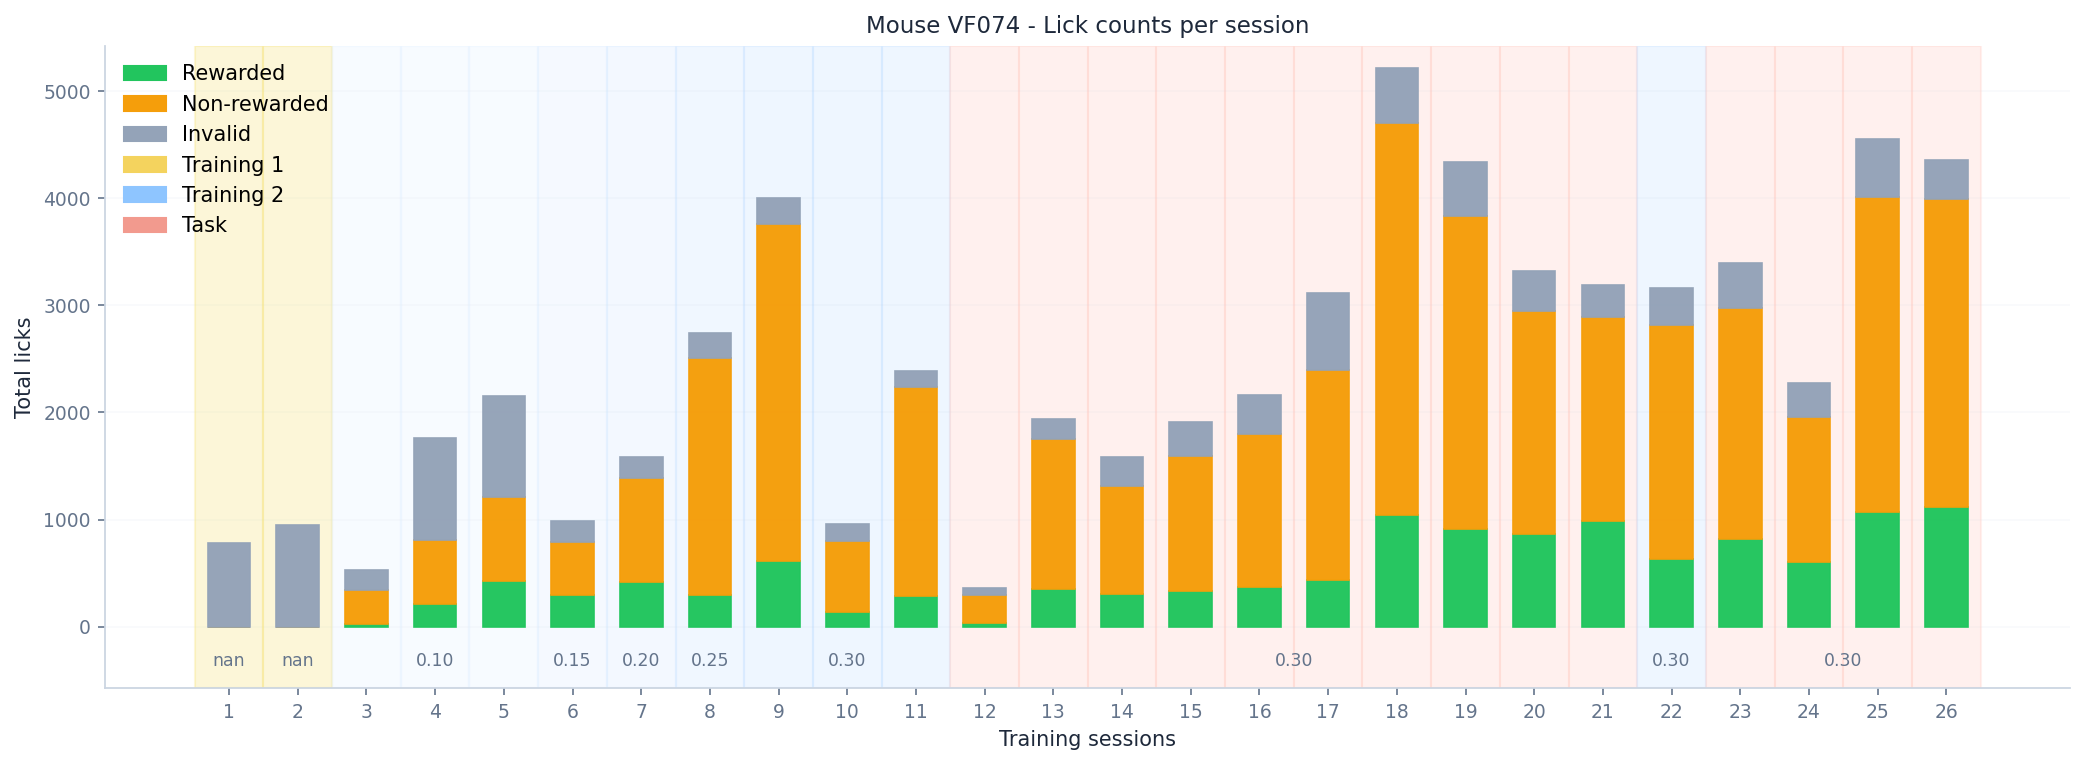

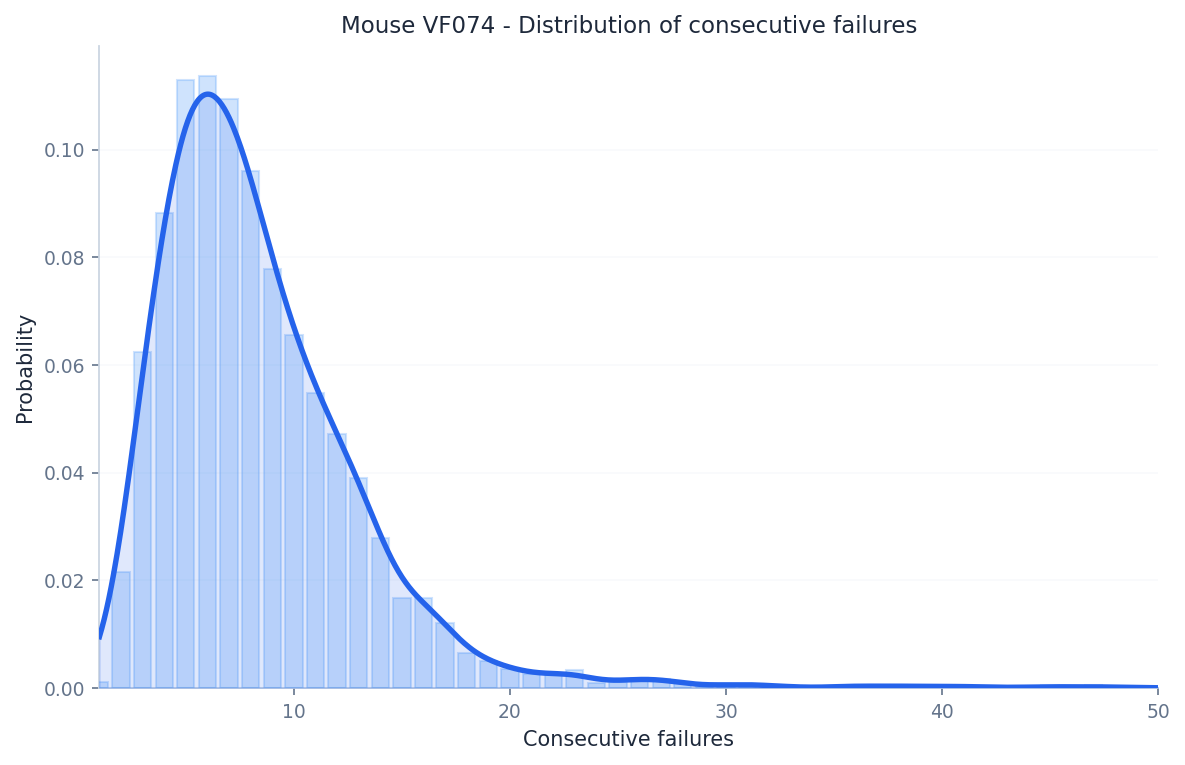

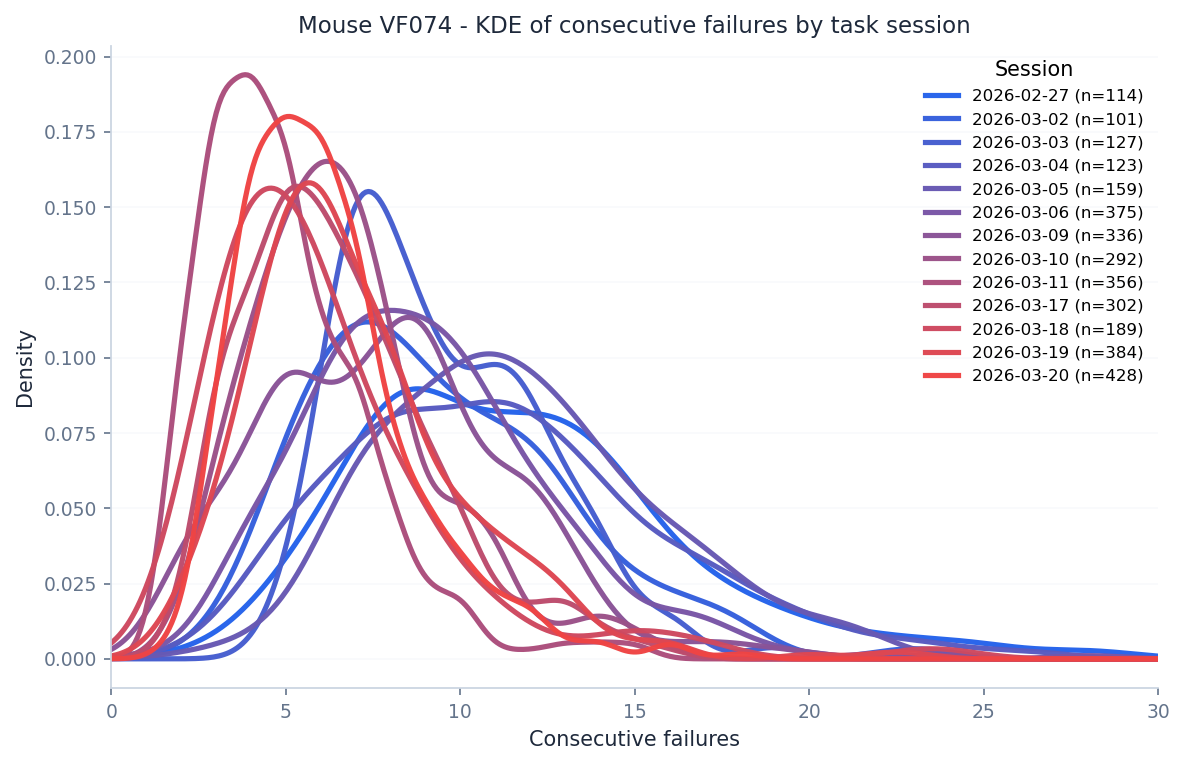

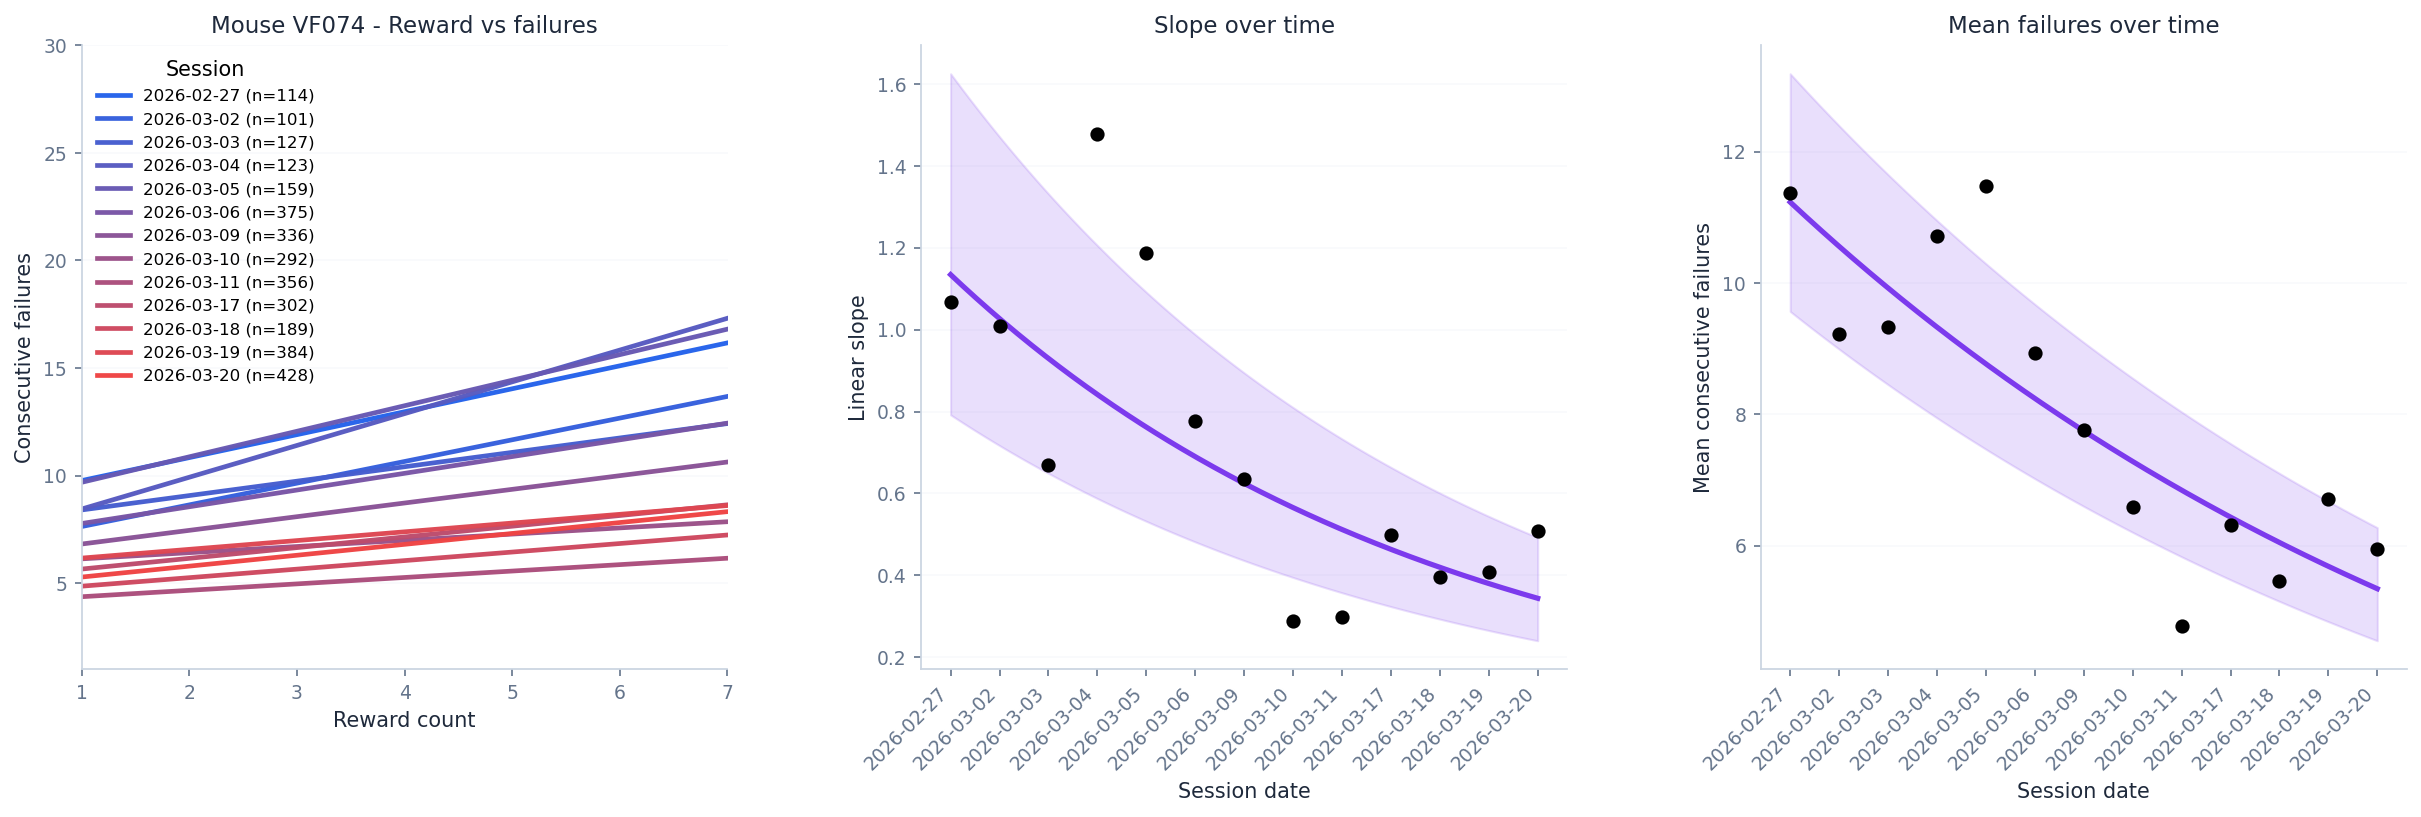


=== bout_count_rewards ===

=== stacked_lick_counts ===

=== histogram_kde_failures ===

=== kde_failures_by_session ===

=== regression_rewards_failures_and_slope ===


In [6]:
global_plots = [
    ("protocol_strip", plot_protocol_strip(df, MOUSE_ID)),
    ("bout_count_rewards", plot_bout_count_rewards(df, MOUSE_ID)),
    ("stacked_lick_counts", plot_stacked_lick_counts(df, MOUSE_ID)),
    ("histogram_kde_failures", plot_histogram_kde_failures(df, MOUSE_ID)),
    ("kde_failures_by_session", plot_kde_failures_by_session(df, MOUSE_ID, session_cmap)),
    (
        "regression_rewards_failures_and_slope",
        plot_regression_rewards_failures_and_slope(df, MOUSE_ID, session_cmap),
    ),
]

for name, fig in global_plots:
    print(f"\n=== {name} ===")
    show_fig(fig, name)


## Plots de la dernière session de VF074


=== last_session_rewards_vs_failures_2026-03-20 ===


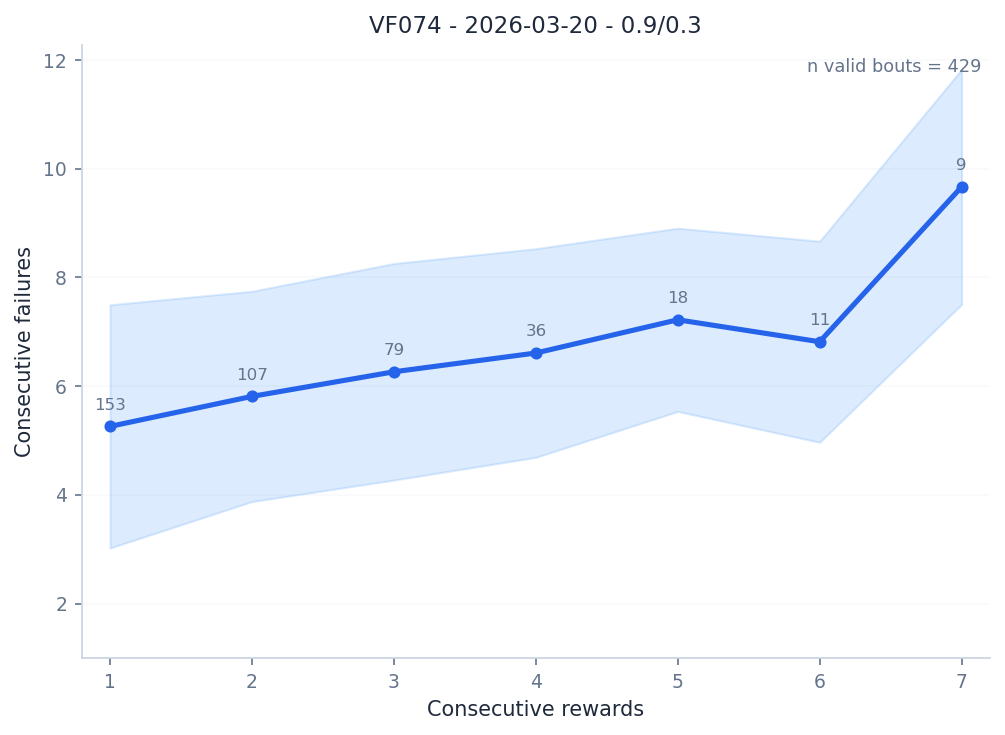

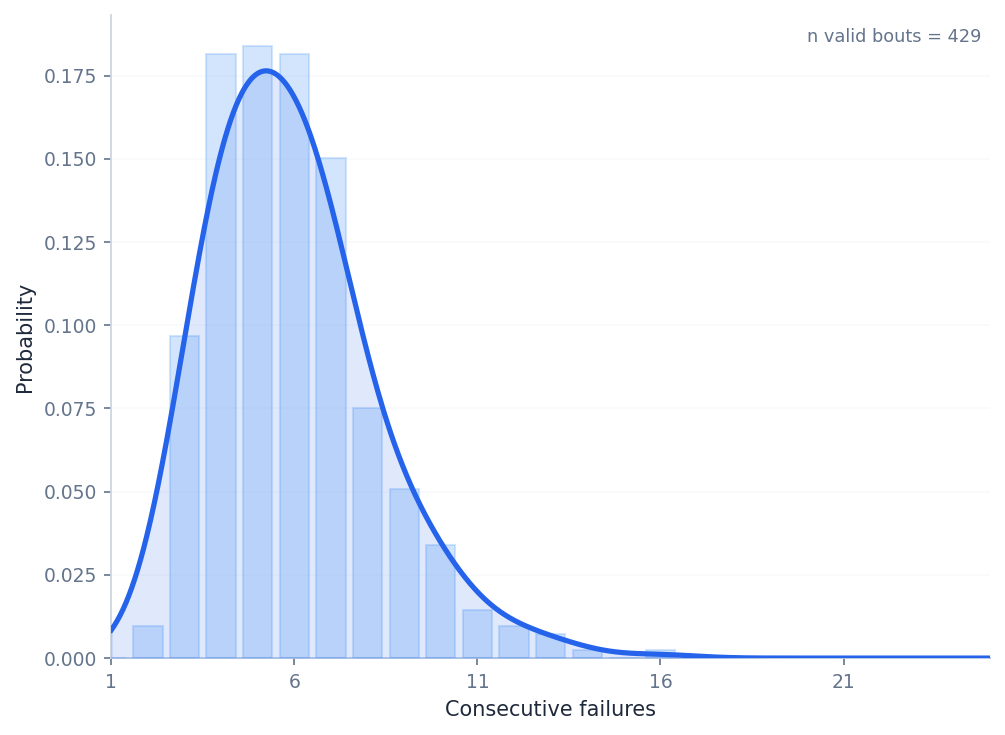


=== last_session_failure_distribution_2026-03-20 ===


In [7]:
session_plots = [
    (
        f"last_session_rewards_vs_failures_{last_date}",
        build_session_plot_rewards_vs_failures(
            session=last_session,
            mouse_id=MOUSE_ID,
            date_str=last_date,
            reward_cut=7,
        ),
    ),
    (
        f"last_session_failure_distribution_{last_date}",
        build_session_plot_failure_distribution(
            session=last_session,
            failure_xlim=(0, 25),
            reward_cut=7,
        ),
    ),
]

for name, fig in session_plots:
    print(f"\n=== {name} ===")
    show_fig(fig, name)


nb bouts détectés : 828
nb valid bouts : 429
nb invalid bouts : 399


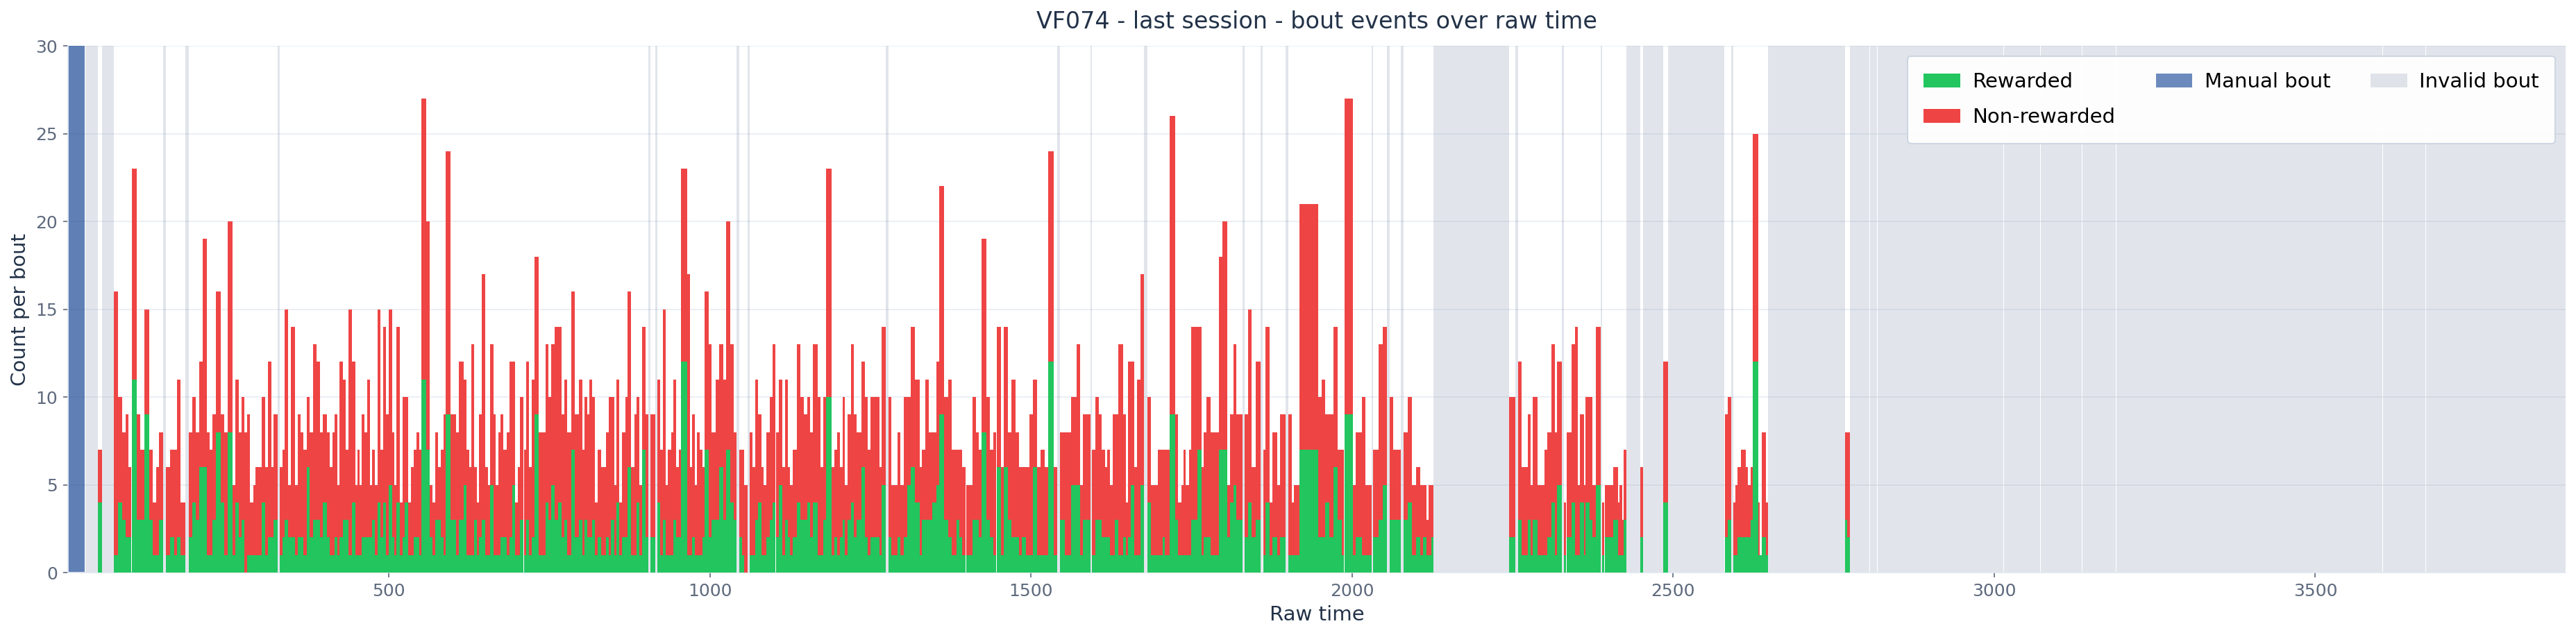

In [28]:
import ast
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# HELPERS
# =============================================================================
def ensure_array(x):
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, list):
        return np.asarray(x, dtype=object)
    if isinstance(x, str):
        try:
            return np.asarray(ast.literal_eval(x), dtype=object)
        except Exception:
            return np.array([], dtype=object)
    return np.array([], dtype=object)


def flatten_if_nested(arr):
    if len(arr) == 0:
        return np.array([], dtype=object)
    if isinstance(arr[0], (list, np.ndarray)):
        out = []
        for block in arr:
            out.extend(np.asarray(block).tolist())
        return np.asarray(out, dtype=object)
    return np.asarray(arr, dtype=object)


def flatten_nested_times(x):
    return flatten_if_nested(ensure_array(x)).tolist()


# =============================================================================
# EXTRACTION
# =============================================================================
def extract_bout_counts(session):
    timestamps = flatten_if_nested(ensure_array(session["Timestamps"])).astype(float)
    bouts = flatten_if_nested(ensure_array(session["Bout for Timestamps"]))

    rewarded = flatten_nested_times(session["Times Rewarded Licks"])
    non_rewarded = flatten_nested_times(session["Times Non Rewarded Licks"])

    if "Manual Reward Bouts" in session.index:
        manual_bouts = set(flatten_if_nested(ensure_array(session["Manual Reward Bouts"])).tolist())
    else:
        manual_bouts = set()

    if "Correct Bouts" in session.index:
        correct_bouts = flatten_if_nested(ensure_array(session["Correct Bouts"]))
        correct_bouts = np.asarray(correct_bouts).astype(bool)
    else:
        correct_bouts = np.array([], dtype=bool)

    if len(timestamps) == 0 or len(bouts) == 0:
        return None

    n = min(len(timestamps), len(bouts))
    timestamps = timestamps[:n]
    bouts = bouts[:n]

    unique_bouts = np.unique(bouts)
    unique_bouts_sorted = np.sort(unique_bouts)

    rows = []
    for i, b in enumerate(unique_bouts_sorted):
        mask = bouts == b
        t = timestamps[mask]

        if len(t) == 0:
            continue

        t_start = float(t.min())
        t_end = float(t.max())
        duration = max(t_end - t_start, 1e-6)
        t_mid = (t_start + t_end) / 2

        r = sum(t_start <= x <= t_end for x in rewarded)
        nr = sum(t_start <= x <= t_end for x in non_rewarded)
        m = 1 if b in manual_bouts else 0

        if len(correct_bouts) > i:
            is_valid = bool(correct_bouts[i])
        else:
            is_valid = True

        rows.append((b, t_start, t_end, duration, t_mid, r, nr, m, is_valid))

    if not rows:
        return None

    arr = np.array(rows, dtype=object)
    return {
        "bout_id": arr[:, 0],
        "t_start": arr[:, 1].astype(float),
        "t_end": arr[:, 2].astype(float),
        "duration": arr[:, 3].astype(float),
        "t_mid": arr[:, 4].astype(float),
        "rewarded": arr[:, 5].astype(float),
        "non_rewarded": arr[:, 6].astype(float),
        "manual": arr[:, 7].astype(float),
        "is_valid": arr[:, 8].astype(bool),
    }


# =============================================================================
# PLOT
# =============================================================================
def plot_bout_lick_timeline(session, title="Bout events over raw time"):
    data = extract_bout_counts(session)

    if data is None:
        print("No data")
        return

    n_bouts = len(data["bout_id"])
    print("nb bouts détectés :", n_bouts)
    print("nb valid bouts :", int(np.sum(data["is_valid"])))
    print("nb invalid bouts :", int(np.sum(~data["is_valid"])))

    t_start = data["t_start"]
    t_end = data["t_end"]
    duration = data["duration"]

    r = data["rewarded"]
    nr = data["non_rewarded"]
    m = data["manual"]
    valid = data["is_valid"]
    invalid = ~valid

    fig_width = min(34, max(18, n_bouts * 0.03))
    fig_height = 6.2

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    green = "#22C55E"
    red = "#EF4444"
    blue = "#3B82F6"
    manual_dark_blue = "#1D4ED8"
    gray_dark = "#94A3B8"
    navy = "#223248"
    grid = "#E2E8F0"

    # Axe Y verrouillé
    ax.set_ylim(0, 30)

    # -------------------------------------------------------------------------
    # INVALID bouts
    # -------------------------------------------------------------------------
    if np.any(invalid):
        first_invalid = True
        for xs, xe in zip(t_start[invalid], t_end[invalid]):
            ax.axvspan(
                xs,
                xe,
                color=gray_dark,
                alpha=0.28,
                lw=0,
                zorder=1,
                label="Invalid bout" if first_invalid else None,
            )
            first_invalid = False

    # -------------------------------------------------------------------------
    # MANUAL bouts (bleu marine)
    # -------------------------------------------------------------------------
    manual_mask = m > 0
    manual_navy = "#0B3D91"

    if np.any(manual_mask):
        first_manual = True
        for xs, xe in zip(t_start[manual_mask], t_end[manual_mask]):
            ax.axvspan(
                xs,
                xe,
                color=manual_navy,
                alpha=0.6,   # assez fort pour éviter effet gris
                lw=0,
                zorder=2,
                label="Manual bout" if first_manual else None,
            )
            first_manual = False

    # -------------------------------------------------------------------------
    # BARS
    # -------------------------------------------------------------------------
    if np.any(valid):
        ax.bar(
            t_start[valid],
            r[valid],
            width=duration[valid],
            align="edge",
            color=green,
            edgecolor="none",
            label="Rewarded",
            zorder=3,
        )

        ax.bar(
            t_start[valid],
            nr[valid],
            width=duration[valid],
            align="edge",
            bottom=r[valid],
            color=red,
            edgecolor="none",
            label="Non-rewarded",
            zorder=3,
        )

        if np.any(m[valid] > 0):
            ax.bar(
                t_start[valid],
                m[valid],
                width=duration[valid],
                align="edge",
                bottom=r[valid] + nr[valid],
                color=blue,
                edgecolor="none",
                label="Manual reward",
                zorder=4,
            )

    # -------------------------------------------------------------------------
    # STYLE
    # -------------------------------------------------------------------------
    ax.set_xlim(t_start.min(), t_end.max())

    ax.set_xlabel("Raw time", fontsize=14, color=navy)
    ax.set_ylabel("Count per bout", fontsize=14, color=navy)
    ax.set_title(title, fontsize=16, color=navy, pad=12)

    ax.grid(axis="y", color=grid, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(grid)
    ax.spines["bottom"].set_color(grid)

    ax.tick_params(axis="both", labelsize=12, colors="#5E6A7D")

    handles, labels = ax.get_legend_handles_labels()
    order = ["Rewarded", "Non-rewarded", "Manual reward", "Manual bout", "Invalid bout"]
    ordered = [(h, l) for name in order for h, l in zip(handles, labels) if l == name]

    if ordered:
        legend = ax.legend(
            [x[0] for x in ordered],
            [x[1] for x in ordered],
            loc="upper right",
            ncol=3,
            fontsize=14,
            frameon=True,
            fancybox=True,
            framealpha=0.95,
            borderpad=0.8,
            labelspacing=0.8,
            handlelength=1.8,
            handletextpad=0.6,
        )
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_edgecolor("#CBD5E1")
        legend.get_frame().set_linewidth(1.0)

    plt.tight_layout()
    plt.show()


# =============================================================================
# TEST
# =============================================================================
plot_bout_lick_timeline(
    session,
    title="VF074 - last session - bout events over raw time"
)